# Fine-Grained Bird Species Classification
This notebook performs fine-grained classification across 10 bird species using:
- provided image features
- handcrafted image features
- pretrained ResNet18 embeddings 
- and several supervised classification models 

The workflow compares feature representations, compares classification models using stratified 5-fold cross-validation, tunes the best model, and evaluates it on a holdout validation set. 


## 1. Setup and Data Loading 

In [ ]:
# Import required libraries
from pathlib import Path 
from typing import Tuple, List, Dict

import numpy as np
import pandas as pd
from PIL import Image 

from sklearn.base import clone 
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier 

import torch 
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader 

from torchvision import models, transforms

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data_dir = Path("../data/task2_data")
output_path = Path("task2_predictions.csv")
RANDOM_STATE = 42

['test_metadata.csv', 'additional_features.csv', 'images', 'task2_code.ipynb', 'engineered_image_features_task2.csv', 'train_metadata.csv', 'color_histogram.csv', 'class_mapping.csv', 'resnet18_features_task2.csv', 'task2_predictions.csv', 'catboost_info', 'hog_pca.csv']


## 2. Handcrafted Feature Engineering

In [4]:
# Load train/test metadata and merge the provided feature files.
def load_csv_features(data_dir: Path) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    train_meta = pd.read_csv(data_dir / "train_metadata.csv")
    test_meta = pd.read_csv(data_dir / "test_metadata.csv")
    class_mapping = pd.read_csv(data_dir / "class_mapping.csv")

    all_meta = pd.concat(
        [
            train_meta[["image_id", "image_path", "class_id", "class_name"]],
            test_meta.assign(class_id=np.nan, class_name=np.nan)[
                ["image_id", "image_path", "class_id", "class_name"]
            ],
        ],
        ignore_index=True,
    )

    features = all_meta.copy()

    for filename in [
        "color_histogram.csv",
        "hog_pca.csv",
        "additional_features.csv"
    ]:
        feature_df = pd.read_csv(data_dir / filename)
        features = features.merge(feature_df, on="image_id", how="left")

    return features, train_meta, class_mapping

In [5]:
# extract extra image features which is useful for fine-grained bird classification
def engineer_image_features(data_dir: Path, metadata: pd.DataFrame) -> pd.DataFrame:

    rows: List[Dict[str, float]] = []

    for _, row in metadata.iterrows():

        image_path = data_dir / row["image_path"]
        image = Image.open(image_path).convert("RGB")

        arr = np.asarray(image).astype(np.float32) / 255.0

        r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
        gray = 0.299 * r + 0.587 * g + 0.114 * b

        image_features = {"image_id": row["image_id"]}

        # RGB statistics
        for name, channel in zip(["r", "g", "b"], [r, g, b]):
            image_features[f"{name}_mean"] = float(channel.mean())
            image_features[f"{name}_std"] = float(channel.std())
            image_features[f"{name}_q25"] = float(np.quantile(channel, 0.25))
            image_features[f"{name}_q50"] = float(np.quantile(channel, 0.50))
            image_features[f"{name}_q75"] = float(np.quantile(channel, 0.75))

        # Colour-opponent features
        rg = r - g
        yb = 0.5 * (r + g) - b

        image_features["rg_mean_abs"] = float(np.mean(np.abs(rg)))
        image_features["yb_mean_abs"] = float(np.mean(np.abs(yb)))
        image_features["rg_std"] = float(np.std(rg))
        image_features["yb_std"] = float(np.std(yb))

        # Brightness features
        image_features["gray_mean"] = float(gray.mean())
        image_features["gray_std"] = float(gray.std())

        # Fine-grained birds often differ in head/wing/body markings,
        # so we use spatial grid features.
        cell = 32

        for i in range(4):
            for j in range(4):
                patch = gray[
                    i * cell:(i + 1) * cell,
                    j * cell:(j + 1) * cell
                ]
                image_features[f"grid_gray_{i}_{j}"] = float(patch.mean())
                image_features[f"grid_gray_std_{i}_{j}"] = float(patch.std())

        # Centre vs border contrast
        centre = gray[32:96, 32:96]

        border_mask = np.ones_like(gray, dtype=bool)
        border_mask[32:96, 32:96] = False
        border = gray[border_mask]

        image_features["centre_mean"] = float(centre.mean())
        image_features["border_mean"] = float(border.mean())
        image_features["centre_border_diff"] = float(centre.mean() - border.mean())

        rows.append(image_features)

    return pd.DataFrame(rows)

In [6]:
# Configure computation device (MPS/CUDA/CPU),
# load pretrained ResNet18 model and remove the
# final classification layer for feature extraction.

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# remove final classifier
resnet.fc = nn.Identity()

resnet = resnet.to(device)
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
# Define image preprocessing pipeline for ResNet18, including resizing, tensor conversion and normalisation.
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
# Create a custom PyTorch Dataset class to load and preprocess images for batch feature extraction.
class ImageFeatureDataset(Dataset):

    def __init__(self, metadata, data_dir):

        self.metadata = metadata.reset_index(drop=True)
        self.data_dir = Path(data_dir)

    def __len__(self):

        return len(self.metadata)

    def __getitem__(self, idx):

        row = self.metadata.iloc[idx]

        image_path = self.data_dir / row["image_path"]

        image = Image.open(image_path).convert("RGB")

        image = resnet_transform(image)

        return image, row["image_id"]

## 3. ResNet18 Feature Extraction

In [9]:
# Extract deep image embeddings from ResNet18 using batched inference and return them as feature vectors.
def extract_resnet_features(
    metadata,
    data_dir,
    batch_size=32
):

    dataset = ImageFeatureDataset(
        metadata,
        data_dir
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    all_features = []
    all_ids = []

    with torch.no_grad():

        for images, image_ids in loader:

            images = images.to(device)

            features = resnet(images)

            features = features.cpu().numpy()

            all_features.append(features)

            all_ids.extend(image_ids)

    all_features = np.vstack(all_features)

    feature_df = pd.DataFrame(
        all_features,
        columns=[
            f"resnet_{i}"
            for i in range(all_features.shape[1])
        ]
    )

    feature_df.insert(0, "image_id", all_ids)

    return feature_df

In [10]:
# Load cached ResNet18 features if available, otherwise extract features from all images and save them for reuse.
train_meta = pd.read_csv(data_dir / "train_metadata.csv")

test_meta = pd.read_csv(data_dir / "test_metadata.csv")

all_meta = pd.concat([train_meta[["image_id", "image_path"]],
                      test_meta[["image_id", "image_path"]]],
                      ignore_index=True)

cache_path = (data_dir / "resnet18_features_task2.csv")

if cache_path.exists():
    resnet_features = pd.read_csv(cache_path)
else:
    resnet_features = extract_resnet_features(all_meta, data_dir)

    resnet_features.to_csv(cache_path,
                           index=False)

## 4. Prepare Data and Build Models

In [11]:
# prepare X, y, X_test for task 2
def prepare_data(data_dir: Path, resnet_features: pd.DataFrame, feature_mode="all"):
    """
    Prepare data using different feature sets.

    feature_mode options:
    - "provided_engineered": provided CSV features + handcrafted image features
    - "resnet_only": ResNet18 features only
    - "all": provided CSV features + engineered features + ResNet18 features
    """

    features, train_meta, class_mapping = load_csv_features(data_dir)

    # cache engineered features
    cache_path = data_dir / "engineered_image_features_task2.csv"

    if cache_path.exists():
        image_features = pd.read_csv(cache_path)
    else:
        image_features = engineer_image_features(
            data_dir,
            features[["image_id", "image_path"]]
        )
        image_features.to_csv(cache_path, index=False)

    metadata_cols = ["image_id", "image_path", "class_id", "class_name"]

    if feature_mode == "provided_engineered":
        features = features.merge(
            image_features,
            on="image_id",
            how="left"
        )

    elif feature_mode == "resnet_only":
        features = features[metadata_cols].merge(
            resnet_features,
            on="image_id",
            how="left"
        )

    elif feature_mode == "all":
        features = features.merge(
            image_features,
            on="image_id",
            how="left"
        )

        features = features.merge(
            resnet_features,
            on="image_id",
            how="left"
        )

    else:
        raise ValueError(
            "feature_mode must be 'provided_engineered', 'resnet_only', or 'all'"
        )

    train_df = features[features["class_id"].notna()].copy()
    test_df = features[features["class_id"].isna()].copy()

    feature_cols = [
        c for c in features.columns
        if c not in ["image_id", "image_path", "class_id", "class_name"]
    ]

    X = train_df[feature_cols].fillna(0.0).values
    y = train_df["class_id"].astype(int).values
    X_test = test_df[feature_cols].fillna(0.0).values

    class_lookup = (
        class_mapping
        .sort_values("class_id")
        .set_index("class_id")["class_name"]
        .to_dict()
    )

    test_ids = test_df[["image_id"]].reset_index(drop=True)

    return X, y, X_test, test_ids, class_lookup

In [12]:
# Build multiple machine learning models and ensemble methods for comparison on the bird classification task.
def build_models() -> Dict[str, object]:
    models = {}

    # Extra Trees: performed well with ResNet features
    models["extra_trees"] = ExtraTreesClassifier(
        n_estimators=500,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=1,
        random_state=RANDOM_STATE
    )

    # LightGBM
    models["lightgbm"] = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.04,
        num_leaves=15,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    )

    # catboost
    models["catboost"] = CatBoostClassifier(
        iterations=250,
        learning_rate=0.04,
        depth=5,
        loss_function="MultiClass",
        eval_metric="Accuracy",
        random_state=RANDOM_STATE,
        verbose=0
    )

    # Soft voting ensemble
    models["ensemble_et_cat_lgbm"] = VotingClassifier(
    estimators=[
        ("et", clone(models["extra_trees"])),
        ("cat", clone(models["catboost"])),
        ("lgbm", clone(models["lightgbm"]))
    ],
    voting="soft",
    weights=[3, 2, 2],
    n_jobs=1
)

    return models

In [13]:
def evaluate_models(X, y, models):
    """
    Compare models using stratified cross-validation.
    """

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    results = []

    for name, model in models.items():

        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="accuracy",
            n_jobs=1
        )

        results.append({
            "model": name,
            "mean_cv_accuracy": scores.mean(),
            "std_cv_accuracy": scores.std(),
            "fold_scores": np.round(scores, 4).tolist()
        })

    return pd.DataFrame(results).sort_values(
        "mean_cv_accuracy",
        ascending=False
    )

In [14]:
# produce validation accuracy, classification report, confusion matrix 

def validation_report(
    X,
    y,
    model,
    class_lookup,
    show_confusion=True,
    show_top_confused=True,
    top_n=5
):
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    labels = sorted(class_lookup.keys())
    target_names = [class_lookup[i] for i in labels]

    acc = accuracy_score(y_val, pred)

    print("Holdout validation accuracy:")
    print(round(acc, 4))

    print("\nClassification report:")
    print(classification_report(
        y_val,
        pred,
        labels=labels,
        target_names=target_names
    ))

    cm = confusion_matrix(y_val, pred, labels=labels)

    cm_df = pd.DataFrame(
        cm,
        index=target_names,
        columns=target_names
    )

    if show_confusion:
        plt.figure(figsize=(12, 10))
        sns.heatmap(
            cm_df,
            annot=True,
            fmt="d",
            cmap="Blues"
        )
        plt.title("Confusion Matrix")
        plt.ylabel("True class")
        plt.xlabel("Predicted class")
        plt.tight_layout()
        plt.show()

    if show_top_confused:
        cm_no_diag = cm.copy()
        np.fill_diagonal(cm_no_diag, 0)

        confused_pairs = []

        for true_idx in range(cm_no_diag.shape[0]):
            for pred_idx in range(cm_no_diag.shape[1]):
                count = cm_no_diag[true_idx, pred_idx]

                if count > 0:
                    confused_pairs.append({
                        "true_class": target_names[true_idx],
                        "predicted_class": target_names[pred_idx],
                        "count": count
                    })

        confused_df = pd.DataFrame(confused_pairs)

        if not confused_df.empty:
            confused_df = confused_df.sort_values(
                "count",
                ascending=False
            ).head(top_n)

            print(f"\nTop {top_n} confused pairs:")
            display(confused_df)
        else:
            print("\nNo misclassified pairs found.")

    return acc, cm_df

In [15]:
# train final model on full training data and save Kaggle CSV
def save_kaggle_predictions(
    model,
    X,
    y,
    X_test,
    test_ids,
    output_path
):

    model.fit(X, y)

    test_pred_ids = model.predict(X_test).astype(int)

    submission = test_ids.copy()
    submission["class_id"] = test_pred_ids

    submission = submission[["image_id", "class_id"]]

    submission.to_csv(output_path, index=False)

    print(f"Saved predictions to: {output_path}")
    print(submission.head())

## 5. Feature Representation Comparison

In [ ]:
# Compare the effectiveness of different feature sets # using the selected classification model.

feature_comparison_results = []

for mode in ["provided_engineered", "resnet_only", "all"]:

    X, y, X_test, test_ids, class_lookup = prepare_data(
        data_dir,
        resnet_features,
        feature_mode=mode
    )

    model = {
        "extra_trees": ExtraTreesClassifier(
            n_estimators=500,
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=1,
            random_state=RANDOM_STATE
        )
    }

    results = evaluate_models(X, y, model)

    feature_comparison_results.append({
        "feature_mode": mode,
        "mean_cv_accuracy": results.iloc[0]["mean_cv_accuracy"],
        "std_cv_accuracy": results.iloc[0]["std_cv_accuracy"],
        "fold_scores": results.iloc[0]["fold_scores"]
    })

feature_comparison_df = pd.DataFrame(feature_comparison_results)

best_feature_row = feature_comparison_df.sort_values(
    "mean_cv_accuracy",
    ascending=False
).iloc[0]

print(
    f"Best feature set: {best_feature_row['feature_mode']} "
    f"(CV accuracy = {best_feature_row['mean_cv_accuracy']:.4f})"
)

feature_comparison_df

Best feature set: all (CV accuracy = 0.8634)


,feature_mode,mean_cv_accuracy,std_cv_accuracy,fold_scores
0,provided_engineered,0.321256,0.059667,"[0.2619, 0.4167, 0.3614, 0.2651, 0.3012]"
1,resnet_only,0.853844,0.041837,"[0.7738, 0.881, 0.8554, 0.8916, 0.8675]"
2,all,0.863368,0.036541,"[0.8095, 0.8929, 0.8313, 0.9036, 0.8795]"


## 6. Model Comparison

Training instances: 417
Test instances: 180
Number of features: 787
Classes: {0: 'American_Goldfinch', 1: 'Blue_Jay', 2: 'Cardinal', 3: 'Herring_Gull', 4: 'House_Sparrow', 5: 'Red_winged_Blackbird', 6: 'Ring_billed_Gull', 7: 'Song_Sparrow', 8: 'Wilson_Warbler', 9: 'Yellow_Warbler'}


,Model,Mean CV Accuracy,Std CV Accuracy,Fold Scores
0,extra_trees,0.8634,0.0365,"0.8095, 0.8929, 0.8313, 0.9036, 0.8795"
1,ensemble_et_cat_lgbm,0.8561,0.0363,"0.8214, 0.8810, 0.8072, 0.8675, 0.9036"
2,catboost,0.8491,0.0450,"0.7619, 0.8571, 0.8675, 0.8916, 0.8675"
3,lightgbm,0.8369,0.0392,"0.8095, 0.8690, 0.7831, 0.8313, 0.8916"



Validation report for: extra_trees
Holdout validation accuracy:
0.8214

Classification report:
                      precision    recall  f1-score   support

  American_Goldfinch       0.80      1.00      0.89         8
            Blue_Jay       1.00      1.00      1.00         8
            Cardinal       1.00      1.00      1.00         8
        Herring_Gull       0.56      0.56      0.56         9
       House_Sparrow       1.00      0.89      0.94         9
Red_winged_Blackbird       1.00      1.00      1.00         9
    Ring_billed_Gull       0.50      0.50      0.50         8
        Song_Sparrow       0.90      1.00      0.95         9
      Wilson_Warbler       0.71      0.62      0.67         8
      Yellow_Warbler       0.71      0.62      0.67         8

            accuracy                           0.82        84
           macro avg       0.82      0.82      0.82        84
        weighted avg       0.82      0.82      0.82        84



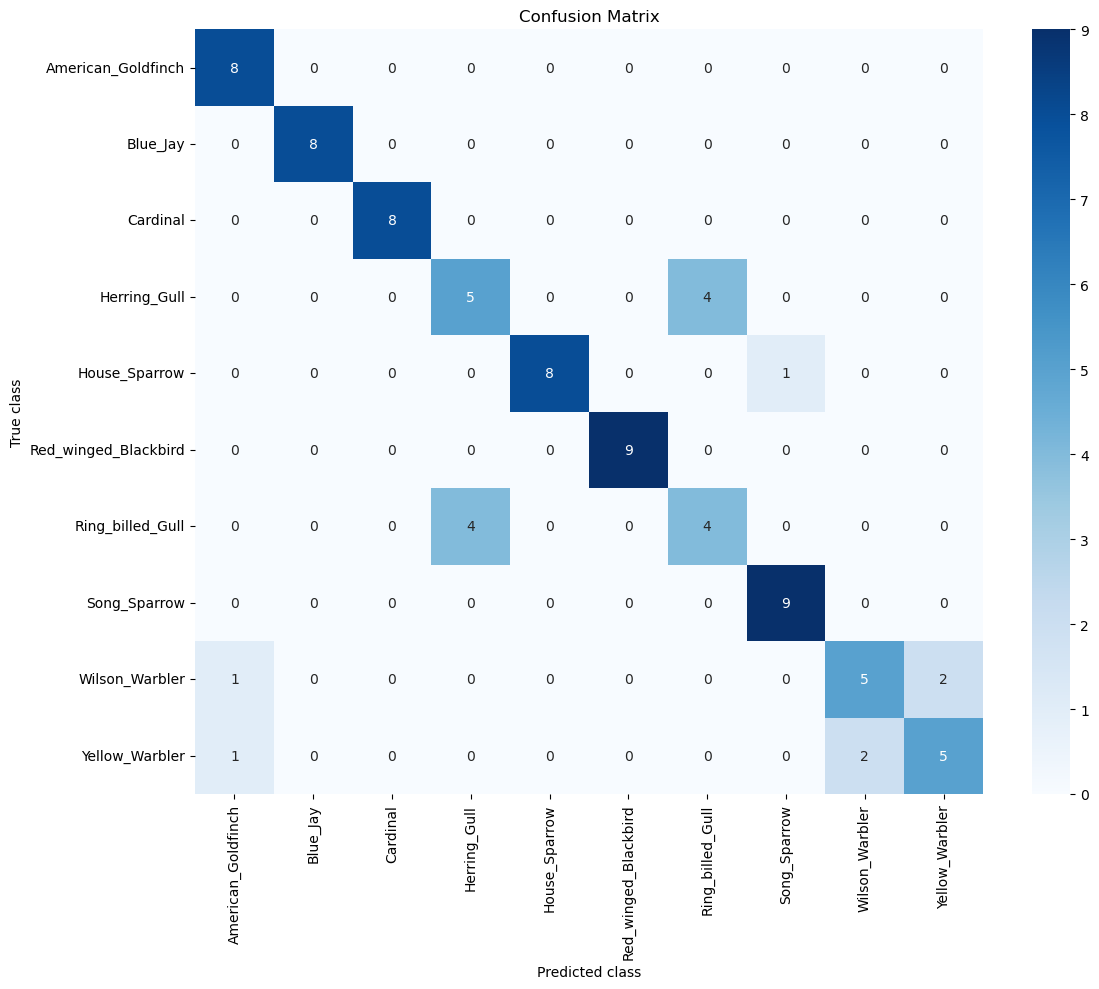


Top 5 confused pairs:


,true_class,predicted_class,count
0,Herring_Gull,Ring_billed_Gull,4
2,Ring_billed_Gull,Herring_Gull,4
4,Wilson_Warbler,Yellow_Warbler,2
6,Yellow_Warbler,Wilson_Warbler,2
1,House_Sparrow,Song_Sparrow,1



Validation report for: ensemble_et_cat_lgbm
Holdout validation accuracy:
0.7857

Classification report:
                      precision    recall  f1-score   support

  American_Goldfinch       0.73      1.00      0.84         8
            Blue_Jay       1.00      1.00      1.00         8
            Cardinal       1.00      1.00      1.00         8
        Herring_Gull       0.60      0.67      0.63         9
       House_Sparrow       0.83      0.56      0.67         9
Red_winged_Blackbird       1.00      1.00      1.00         9
    Ring_billed_Gull       0.50      0.50      0.50         8
        Song_Sparrow       0.73      0.89      0.80         9
      Wilson_Warbler       0.71      0.62      0.67         8
      Yellow_Warbler       0.83      0.62      0.71         8

            accuracy                           0.79        84
           macro avg       0.79      0.79      0.78        84
        weighted avg       0.79      0.79      0.78        84



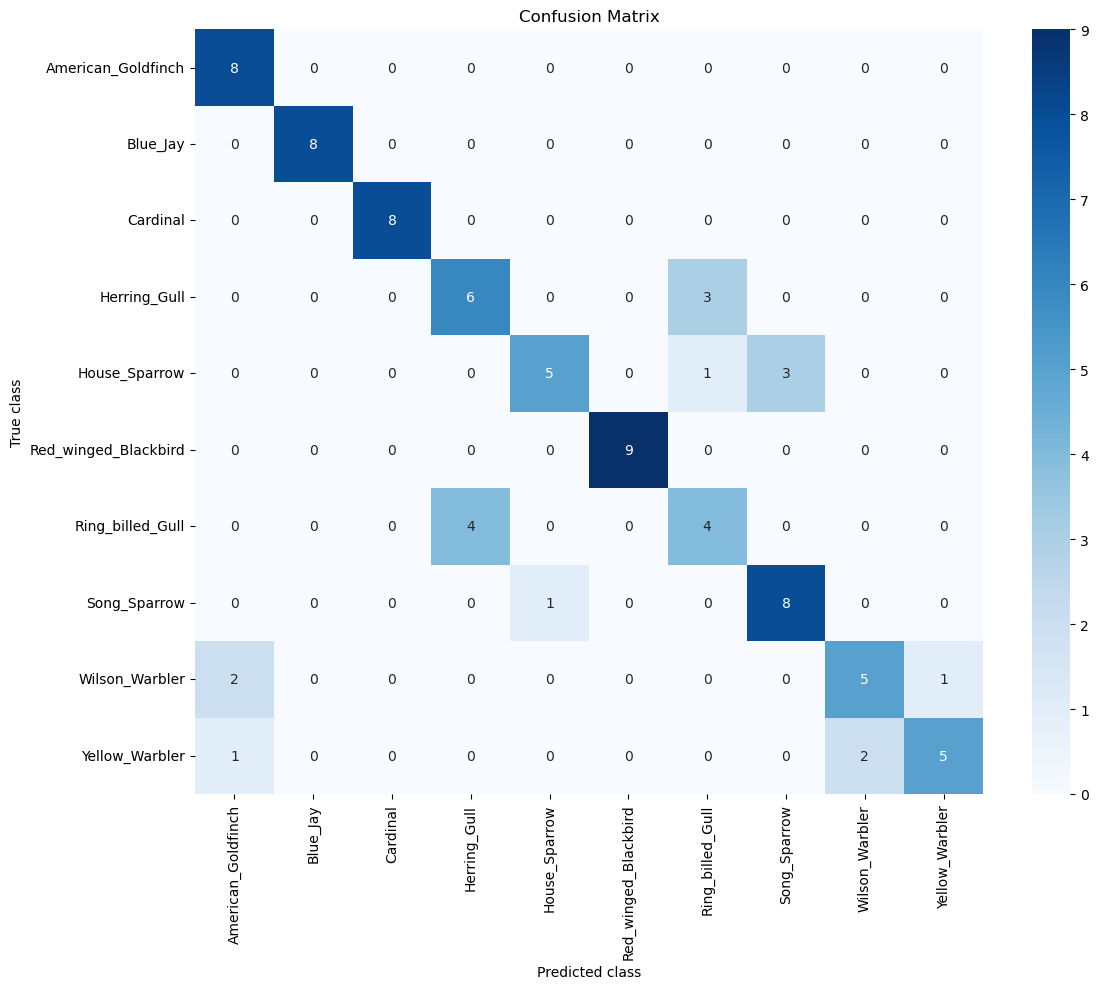


Top 5 confused pairs:


,true_class,predicted_class,count
3,Ring_billed_Gull,Herring_Gull,4
0,Herring_Gull,Ring_billed_Gull,3
2,House_Sparrow,Song_Sparrow,3
5,Wilson_Warbler,American_Goldfinch,2
8,Yellow_Warbler,Wilson_Warbler,2



Validation report for: catboost
Holdout validation accuracy:
0.8214

Classification report:
                      precision    recall  f1-score   support

  American_Goldfinch       0.89      1.00      0.94         8
            Blue_Jay       1.00      1.00      1.00         8
            Cardinal       1.00      1.00      1.00         8
        Herring_Gull       0.50      0.56      0.53         9
       House_Sparrow       1.00      0.89      0.94         9
Red_winged_Blackbird       1.00      1.00      1.00         9
    Ring_billed_Gull       0.43      0.38      0.40         8
        Song_Sparrow       0.90      1.00      0.95         9
      Wilson_Warbler       0.67      0.75      0.71         8
      Yellow_Warbler       0.83      0.62      0.71         8

            accuracy                           0.82        84
           macro avg       0.82      0.82      0.82        84
        weighted avg       0.82      0.82      0.82        84



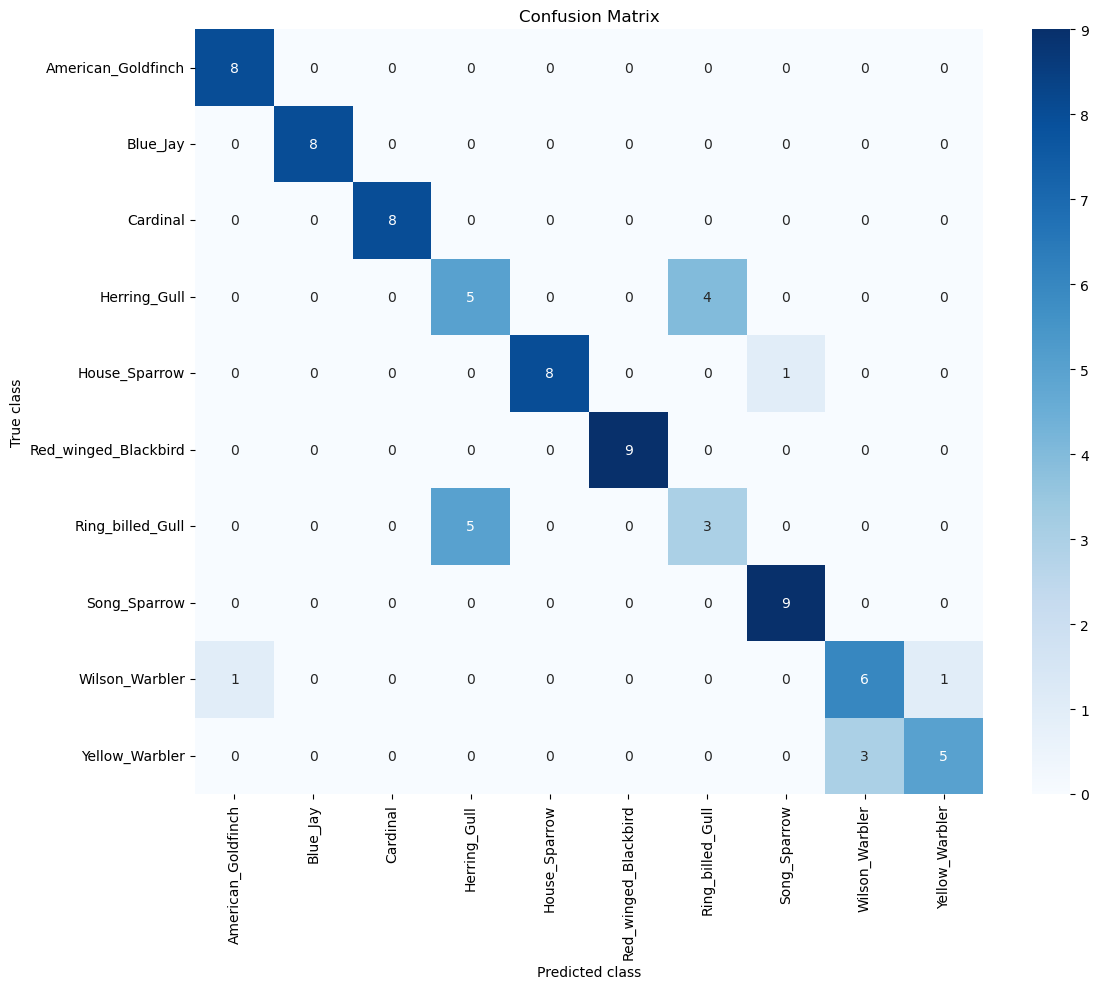


Top 5 confused pairs:


,true_class,predicted_class,count
2,Ring_billed_Gull,Herring_Gull,5
0,Herring_Gull,Ring_billed_Gull,4
5,Yellow_Warbler,Wilson_Warbler,3
1,House_Sparrow,Song_Sparrow,1
3,Wilson_Warbler,American_Goldfinch,1



Best model before tuning: extra_trees


In [ ]:
# Prepare the final feature set, display dataset statistics, train top 3 models and evaluate their performance.
feature_mode = "all"

X, y, X_test, test_ids, class_lookup = prepare_data(
    data_dir,
    resnet_features,
    feature_mode=feature_mode
)

print(f"Training instances: {X.shape[0]}")
print(f"Test instances: {X_test.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print("Classes:", class_lookup)

models = build_models()

results = evaluate_models(X, y, models)

results_table = results.copy()

results_table["mean_cv_accuracy"] = (
    results_table["mean_cv_accuracy"]
    .round(4)
)

results_table["std_cv_accuracy"] = (
    results_table["std_cv_accuracy"]
    .round(4)
)

# convert fold scores to compact string
results_table["fold_scores"] = (
    results_table["fold_scores"]
    .apply(lambda x: ", ".join([f"{v:.4f}" for v in x]))
)

results_table.columns = [
    "Model",
    "Mean CV Accuracy",
    "Std CV Accuracy",
    "Fold Scores"
]

results_table = results_table.sort_values(
    "Mean CV Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_table)

top3_models = results.head(3)["model"].tolist()

for model_name in top3_models:

    print("\n" + "=" * 60)
    print(f"Validation report for: {model_name}")
    print("=" * 60)

    validation_report(
        X,
        y,
        clone(models[model_name]),
        class_lookup,
        show_confusion=True,
        show_top_confused=True,
        top_n=5
    )

best_model_name = results.iloc[0]["model"]

print(f"\nBest model before tuning: {best_model_name}")

## 7. Hyperparameter Tuning

In [ ]:
# tune Extra Trees hyperparameter after model comparison 
et_results = []

for n_estimators in [300, 500, 800]:
    for min_samples_leaf in [1, 2, 3]:

        model = ExtraTreesClassifier(
            n_estimators=n_estimators,
            max_features="sqrt",
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced",
            n_jobs=1,
            random_state=RANDOM_STATE
        )

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="accuracy",
            n_jobs=1
        )

        et_results.append({
            "n_estimators": n_estimators,
            "min_samples_leaf": min_samples_leaf,
            "mean_cv_accuracy": scores.mean(),
            "std_cv_accuracy": scores.std(),
            "fold_scores": np.round(scores, 4).tolist()
        })

et_results_df = pd.DataFrame(et_results).sort_values(
    "mean_cv_accuracy",
    ascending=False
)

et_results_df

,n_estimators,min_samples_leaf,mean_cv_accuracy,std_cv_accuracy,fold_scores
4,500,2,0.863368,0.036541,"[0.8095, 0.8929, 0.8313, 0.9036, 0.8795]"
7,800,2,0.860987,0.022969,"[0.8214, 0.869, 0.8554, 0.8916, 0.8675]"
6,800,1,0.856225,0.033334,"[0.7976, 0.869, 0.8434, 0.8795, 0.8916]"
3,500,1,0.856196,0.026919,"[0.8214, 0.8571, 0.8313, 0.8795, 0.8916]"
1,300,2,0.856168,0.036005,"[0.7976, 0.8929, 0.8313, 0.8795, 0.8795]"
2,300,3,0.844177,0.012427,"[0.8214, 0.8452, 0.8434, 0.8554, 0.8554]"
8,800,3,0.844177,0.021089,"[0.8214, 0.8452, 0.8193, 0.8675, 0.8675]"
5,500,3,0.841767,0.017292,"[0.8333, 0.8333, 0.8193, 0.8675, 0.8554]"
0,300,1,0.836976,0.025455,"[0.7976, 0.8571, 0.8434, 0.8675, 0.8193]"


## 8. Final Model Evaluation and Predictions 

Best Extra Trees parameters: n_estimators=500, min_samples_leaf=2
Holdout validation accuracy:
0.8214

Classification report:
                      precision    recall  f1-score   support

  American_Goldfinch       0.80      1.00      0.89         8
            Blue_Jay       1.00      1.00      1.00         8
            Cardinal       1.00      1.00      1.00         8
        Herring_Gull       0.56      0.56      0.56         9
       House_Sparrow       1.00      0.89      0.94         9
Red_winged_Blackbird       1.00      1.00      1.00         9
    Ring_billed_Gull       0.50      0.50      0.50         8
        Song_Sparrow       0.90      1.00      0.95         9
      Wilson_Warbler       0.71      0.62      0.67         8
      Yellow_Warbler       0.71      0.62      0.67         8

            accuracy                           0.82        84
           macro avg       0.82      0.82      0.82        84
        weighted avg       0.82      0.82      0.82        84



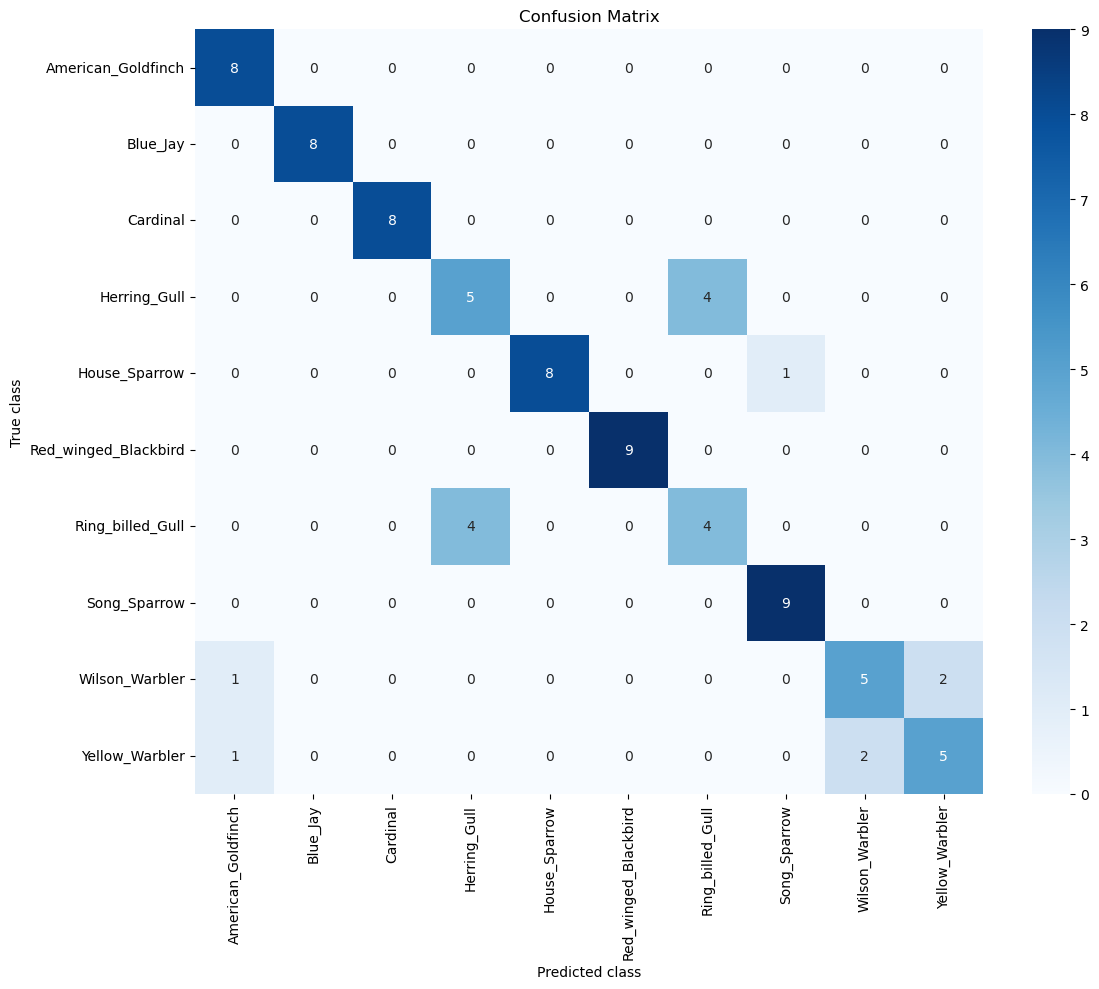


Top 5 confused pairs:


,true_class,predicted_class,count
0,Herring_Gull,Ring_billed_Gull,4
2,Ring_billed_Gull,Herring_Gull,4
4,Wilson_Warbler,Yellow_Warbler,2
6,Yellow_Warbler,Wilson_Warbler,2
1,House_Sparrow,Song_Sparrow,1


Saved predictions to: task2_predictions.csv
    image_id  class_id
0  test_0000         9
1  test_0001         2
2  test_0002         0
3  test_0003         2
4  test_0004         0


In [19]:
best_params = et_results_df.iloc[0]

best_n_estimators = int(best_params["n_estimators"])
best_min_samples_leaf = int(best_params["min_samples_leaf"])

print(
    f"Best Extra Trees parameters: "
    f"n_estimators={best_n_estimators}, "
    f"min_samples_leaf={best_min_samples_leaf}"
)

final_model = ExtraTreesClassifier(
    n_estimators=best_n_estimators,
    max_features="sqrt",
    min_samples_leaf=best_min_samples_leaf,
    class_weight="balanced",
    n_jobs=1,
    random_state=RANDOM_STATE
)

validation_report(
    X,
    y,
    clone(final_model),
    class_lookup
)

save_kaggle_predictions(
    clone(final_model),
    X,
    y,
    X_test,
    test_ids,
    output_path
)